In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df=pd.read_csv(r"data\Coffee Shop Sales.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  object 
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 12.5+ MB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [6]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [7]:
df["transaction_time"] = pd.to_datetime(df["transaction_time"].astype(str), format="%H:%M:%S").dt.time


In [8]:
# correcting datatypes
df["transaction_date"]=pd.to_datetime(df["transaction_date"],format="%d-%m-%Y")	

In [9]:
df = df.drop_duplicates()


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [11]:
df["transaction_time"].head()



0    07:06:11
1    07:08:56
2    07:14:04
3    07:20:24
4    07:22:41
Name: transaction_time, dtype: object

In [12]:
df["hour"]=pd.to_datetime(df["transaction_time"].astype(str)).dt.hour

C:\Users\Hamsashree\AppData\Local\Temp\ipykernel_7792\2689954653.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["hour"]=pd.to_datetime(df["transaction_time"].astype(str)).dt.hour


In [13]:
df["day"] =df["transaction_date"].dt.day_name()

In [14]:
df["revenue"] = df["transaction_qty"] * df["unit_price"]


In [15]:
df[["hour", "day", "revenue"]].head()


,hour,day,revenue
0,7,Sunday,6.0
1,7,Sunday,6.2
2,7,Sunday,9.0
3,7,Sunday,2.0
4,7,Sunday,6.2


In [16]:
df["store_location"] = df["store_location"].str.strip().str.title()
df["product_category"] = df["product_category"].str.strip().str.title()
df["product_type"] = df["product_type"].str.strip().str.title()
df["product_detail"] = df["product_detail"].str.strip().str.title()


In [17]:
df["transaction_qty"].describe()
df["unit_price"].describe()
df["revenue"].describe()


count    149116.000000
mean          4.686367
std           4.227099
min           0.800000
25%           3.000000
50%           3.750000
75%           6.000000
max         360.000000
Name: revenue, dtype: float64

In [18]:
df = df[df["transaction_qty"] > 0]
df = df[df["unit_price"] > 0]


In [19]:
df.to_csv("data/Coffee_Shop_Sales_Cleaned.csv", index=False)


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
 11  hour              149116 non-null  int32         
 12  day               149116 non-null  object        
 13  revenue           149116 non-null  float64       
dtypes: d

In [21]:
#Total revenue overview
round(df["revenue"].sum(),2)

np.float64(698812.33)

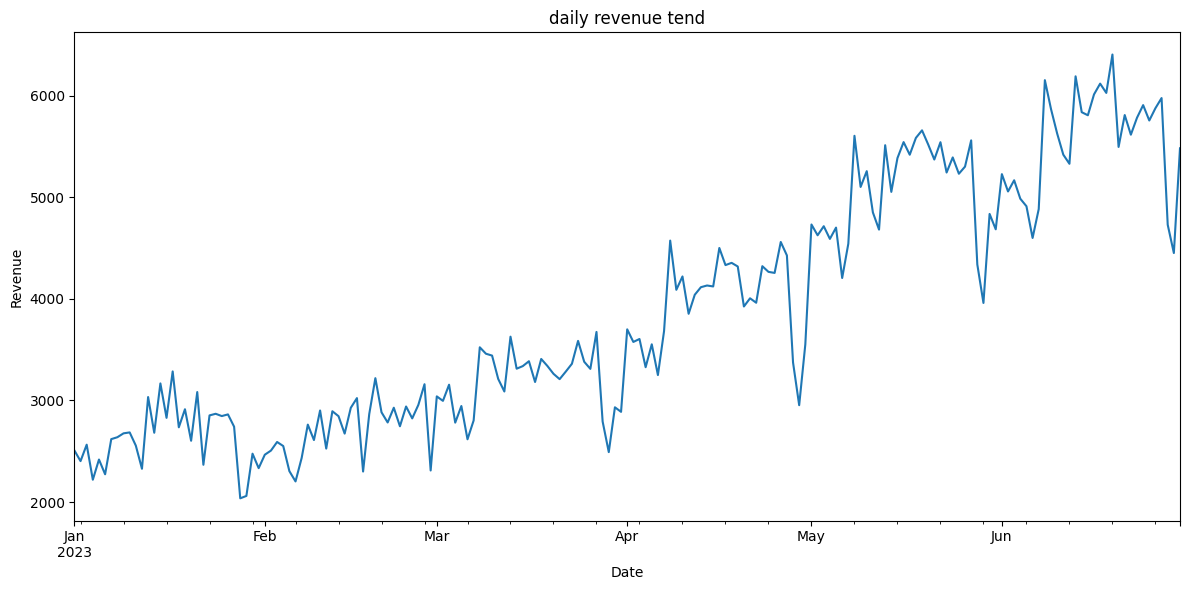

In [22]:
#Daily revenue trend (line chart)
daily=df.groupby("transaction_date")["revenue"].sum()
#daily.head()
daily.plot(figsize=(12,6))
plt.title("daily revenue tend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

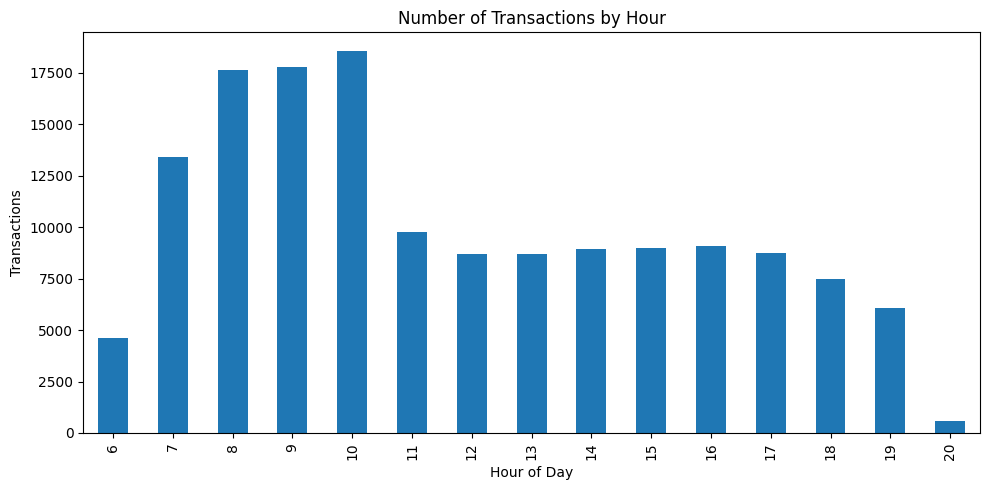

In [23]:
#Busiest hours (bar chart)
hourly=df.groupby("hour")["transaction_id"].count()
hourly.plot(kind="bar",figsize=(10,5))
plt.title("Number of Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transactions")
plt.tight_layout()
plt.show()

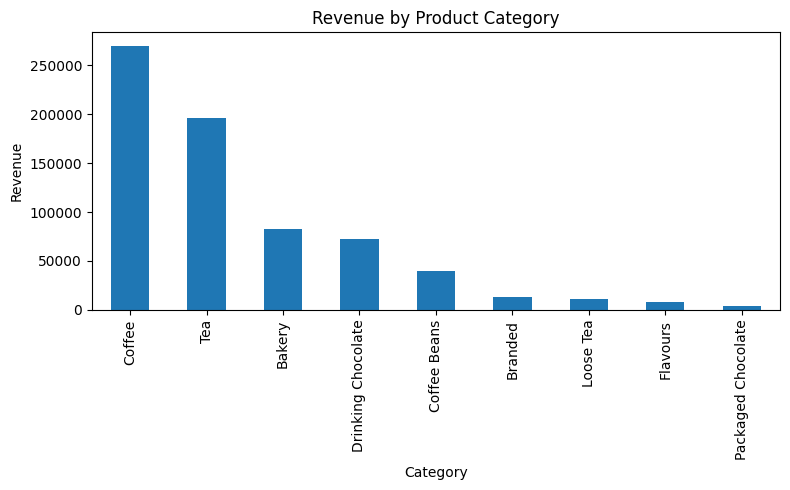

In [24]:
#Best-selling product categories
category=df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

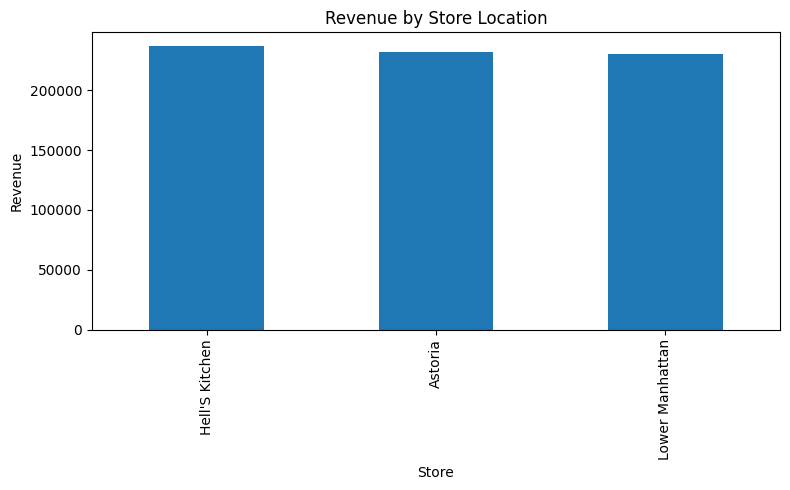

In [25]:
#Store location comparison
stores = df.groupby("store_location")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
stores.plot(kind="bar")
plt.title("Revenue by Store Location")
plt.xlabel("Store")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


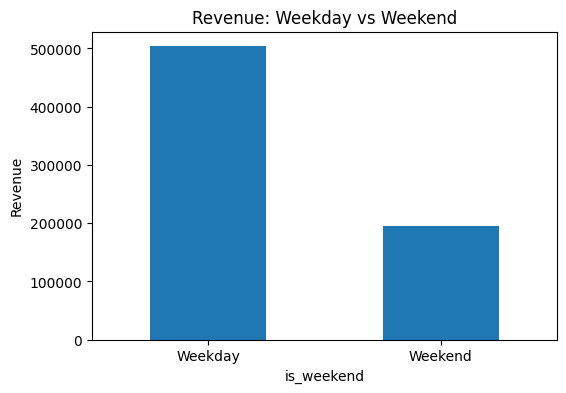

In [26]:
df["is_weekend"] = df["day"].isin(["Saturday", "Sunday"])

weekend = df.groupby("is_weekend")["revenue"].sum()

weekend.plot(kind="bar", figsize=(6,4))
plt.xticks([0,1], ["Weekday", "Weekend"], rotation=0)
plt.title("Revenue: Weekday vs Weekend")
plt.ylabel("Revenue")
plt.show()


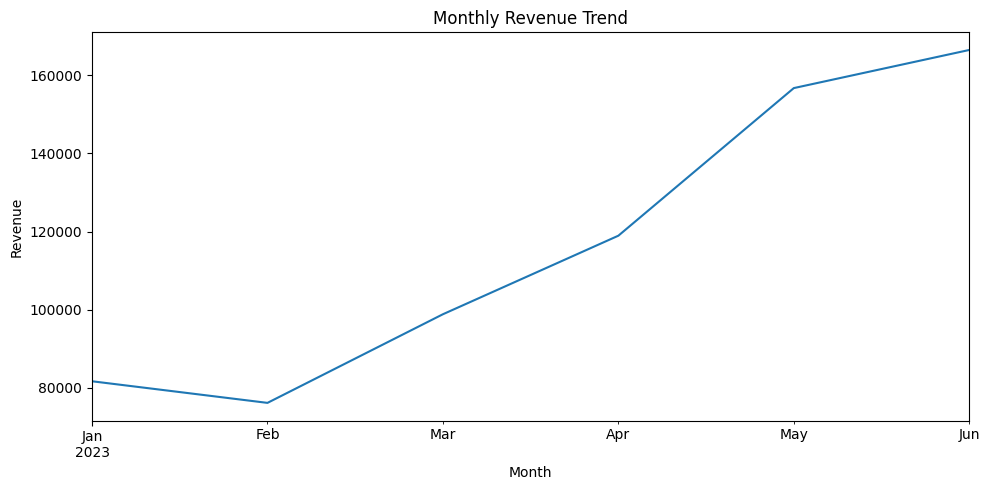

In [27]:
df["month"] = df["transaction_date"].dt.to_period("M")
monthly = df.groupby("month")["revenue"].sum()

monthly.plot(kind="line", figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


In [28]:
df["year"]=df["transaction_date"].dt.year
df["month"]=df["transaction_date"].dt.month

In [29]:
monthly_sales = df.groupby(["year","month"])["revenue"].sum().reset_index()

In [32]:
monthly_sales['Monthly_Growth_%'] = monthly_sales['revenue'].pct_change() * 100


In [31]:
monthly_sales.head()

,year,month,revenue,Monthly_Growth_%
0,2023,1,81677.74,NaN
1,2023,2,76145.19,-6.773633
2,2023,3,98834.68,29.797667
3,2023,4,118941.08,20.343466
4,2023,5,156727.76,31.769242
